# Position rules on one instrument: an aggregate

Every portfolio in this notebook trades the **same** instrument on the
**same** days: the same-day-expiry nearest-out-of-the-money call and put
at 15:30 ET, held to the official close. Nothing here changes a variance
forecast, fits a classifier, or moves a strike on a buying day. What
changes is the **position** $q_t$ — and, in one family, the notional
$m_t$ carried on that position — both known at 15:30.

The signal is the one already built in `atm_straddle_rv_iv.ipynb`:

$$s_t=\widehat{RV}_t-\mathrm{IV}^2_{\mathrm{30min},t},\qquad
R_t=\frac{\text{settlement payout}_t}{\text{entry premium}_t}-1 .$$

Three families are scored, each against the same control:

- **A — position, not size.** always short; $\mathrm{sign}(s)$; a
  threshold rule $q=+1$ iff $s>c$; and the long-only leg as a
  *diagnostic row only*, so the mean decomposition stays visible.
- **B — asymmetric capital on the same package.** A notional multiplier
  $m_t$ on the existing $q_t$: $R'_t=m_t q_t R_t$, with $m$ free to
  differ between buying and selling days.
- **C — defined-risk shorts, uncapped longs.** Wings bought on the
  selling days only; buying days keep the plain package.

**The frame has moved since this aggregate was commissioned.** The
request was written against 871 days with a $\mathrm{sign}(s)$ Sharpe
ratio of 1.63 and an always-short control of 0.28. Those are the old
frame. This notebook reproduces **today's** numbers instead: the common
frame is **866 days** (the library's early-close rule drops the frozen
half sessions and the session-date fit mask is in force), the published
headline is $\mathrm{sign}(s)$ on the **block-diagonal ridge** at an
annualized Sharpe ratio of **1.338** ($t=2.481$) at the midpoint and
**0.870** when the entry pays the crossed spread, and the always-short
control is **0.204**. §1 prints all of them.

**Model set.** `atm_straddle_lib.MODEL_ORDER` carries eight tags; the
eighth, the block-diagonal ridge without the FOMC columns, is a
diagnostic for those channels rather than a forecast in its own right,
so the aggregate scores the **seven** forecasts.

**Convention.** Every table is printed before it is used or written.
Every causal statistic — a threshold percentile, a past median of
implied variance, a fraction of wealth — is an expanding window over
days strictly before $t$ with at least 63 sessions of history. The
default rule is declared in §2, in words, before a single grid is
printed: the grid is sensitivity, never selection.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl   # shared helpers: rule positions, summary rows, wings, information ratio
SRC = REPO / "results" / "atm_straddle_0dte_1530"          # the daily tables written by the 15:30 deck
OUT = REPO / "results" / "atm_straddle_0dte_1530_aggregate"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache, shared with the 15:30 deck: every entry is keyed on
# the source file's size+mtime, so a changed input can never serve a stale
# hit. Delete the directory to force a cold rebuild.
CACHE = SRC / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:      ", REPO)
print("daily books:", SRC)
print("written to: ", OUT)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo:       C:\Users\james\CC Allowed\harxhar-0dte-professor
daily books: C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530
written to:  C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate


## 1. The seven forecasts, the common days, and the control

The daily tables are read as written — no chain is rescanned here. Each
row is one expiration day and carries the instrument (`entry`, `exit`,
`R`, `S`, `K_c`, `K_p`, the four leg quotes), the quoted variance
`iv_var`, the forecast `rv_hat`, and the signal.

Three things are checked before anything is scored.

1. **One instrument.** The columns that describe the trade — not the
   forecast — must be bit-identical across the seven tables. The cell
   asserts it.
2. **One common index.** Every portfolio is scored on the days common to
   all seven tables.
3. **The control takes no forecast**, so its seven rows must coincide.
   The cell asserts that too, and only then prints one row.

The package bid and ask are built from the legs (`bid_c + bid_p`,
`ask_c + ask_p`); there is no stored package-bid column. The midpoint of
that package is the entry premium, which the cell verifies to floating
point.

In [2]:
MODEL_ORDER = [t for t in asl.MODEL_ORDER if t != "blk2_inc"]   # blk2_inc is the no-FOMC diagnostic ridge, not a forecast in the model set
LABEL = {t: asl.YHAT_LABEL[t] for t in MODEL_ORDER}
print("model set:", len(MODEL_ORDER), "of", len(asl.MODEL_ORDER), "tags; excluded:",
      [t for t in asl.MODEL_ORDER if t not in MODEL_ORDER], "=", asl.YHAT_LABEL["blk2_inc"])

books = {}
for tag in MODEL_ORDER:
    p = SRC / f"daily_{tag}.parquet"
    st = os.stat(p)
    px = pd.read_parquet(p)
    px.index = pd.to_datetime(px.index)
    px.index.name = "day"
    px = px.sort_index()
    if "bid_entry" not in px.columns:
        px["bid_entry"] = px["bid_c"].astype(float) + px["bid_p"].astype(float)
        px["ask_entry"] = px["ask_c"].astype(float) + px["ask_p"].astype(float)
    books[tag] = px
    print(f"{tag:8s} {LABEL[tag]:36s} {len(px):4d} days  "
          f"{px.index.min().date()} -> {px.index.max().date()}   ({st.st_size} bytes, mtime_ns {st.st_mtime_ns})")

common = None
for tag in MODEL_ORDER:
    common = books[tag].index if common is None else common.intersection(books[tag].index)
common = common.sort_values()
print("---")
print(f"common days: {len(common)}  {common.min().date()} -> {common.max().date()}")
print("days per calendar year:", pd.Series(0, index=common).groupby(common.year).size().to_dict())

INSTRUMENT_COLS = ["R", "entry", "exit", "S", "K_c", "K_p",
                   "bid_c", "ask_c", "bid_p", "ask_p", "iv_var"]
gap = max(
    float((books[t].loc[common, c].astype(float) - books["blk2"].loc[common, c].astype(float)).abs().max())
    for t in MODEL_ORDER for c in INSTRUMENT_COLS
)
print(f"largest disagreement across the {len(MODEL_ORDER)} tables in {INSTRUMENT_COLS}: {gap:.3e}")
assert gap == 0.0, "the daily tables disagree about the instrument"

px0 = books["blk2"].loc[common]
mid_err = float((0.5 * (px0["bid_entry"] + px0["ask_entry"]) - px0["entry"]).abs().max())
print(f"package midpoint (bid_c+bid_p, ask_c+ask_p) vs the stored entry premium: max |diff| = {mid_err:.3e}")

R = px0["R"].astype(float)
q_short = pd.Series(-1.0, index=common)
as_rows = pd.DataFrame({tag: asl.rule_row(-books[tag].loc[common, "R"].astype(float), q_short)
                        for tag in MODEL_ORDER}).T
spread_as = float((as_rows["Sharpe_ann"].max() - as_rows["Sharpe_ann"].min()))
print(f"always short across the {len(MODEL_ORDER)} forecasts: Sharpe spread = {spread_as:.3e}")
assert spread_as == 0.0, "always short is not model-invariant"
print("always short takes no forecast, so one row stands for all seven:")
print(asl.rule_row(-R, q_short).to_string())

print("---")
sz0 = asl.rule_sizes(books["blk2"])
sign_row = asl.rule_row((sz0["sign(s)"] * books["blk2"]["R"]).loc[common], sz0["sign(s)"].loc[common])
print("sign(s) on the block-diagonal ridge, midpoint fill:")
print(sign_row.to_string())
crossed_sign = asl.crossed_premium_return(sz0["sign(s)"].loc[common], px0["exit"], px0["bid_entry"], px0["ask_entry"])
n_untradeable = asl.crossed_untradeable_count(sz0["sign(s)"].loc[common], px0["bid_entry"], px0["ask_entry"])
crossed_row = asl.rule_row(crossed_sign, sz0["sign(s)"].loc[common])
print(f"sign(s) when the entry pays the crossed spread ({n_untradeable} untradeable rows): "
      f"Sharpe {float(crossed_row['Sharpe_ann']):.3f}")
print("---")
print(f"HEADLINE REPRODUCED on {len(common)} days: "
      f"sign(s) Sharpe {float(sign_row['Sharpe_ann']):.3f} (t {float(sign_row['t_mean']):.3f}) at the midpoint, "
      f"{float(crossed_row['Sharpe_ann']):.3f} at the crossed spread; "
      f"always short {float(asl.rule_row(-R, q_short)['Sharpe_ann']):.3f}")
print(f"annualization: sqrt({asl.PERIODS_PER_YEAR:.0f}) per trade day; "
      f"realized trade days per year on this frame = {asl.trades_per_year(common):.1f}")


model set: 7 of 8 tags; excluded: ['blk2_inc'] = block-diagonal ridge, without the FOMC columns


a0       baseline (HAR + calendar OLS)         866 days  2020-01-03 -> 2024-04-30   (270432 bytes, mtime_ns 1788680210564581200)
blk2     block-diagonal ridge                  866 days  2020-01-03 -> 2024-04-30   (270440 bytes, mtime_ns 1788680210594989500)
lgbm     LightGBM                              866 days  2020-01-03 -> 2024-04-30   (270436 bytes, mtime_ns 1788680210673296000)
xgb      XGBoost                               866 days  2020-01-03 -> 2024-04-30   (270434 bytes, mtime_ns 1788680210699397800)
lasso_t  lasso (causally tuned)                866 days  2020-01-03 -> 2024-04-30   (270445 bytes, mtime_ns 1788680210725109100)
lasso_f  lasso (fixed 1e-4)                    866 days  2020-01-03 -> 2024-04-30   (270440 bytes, mtime_ns 1788680210751951000)
enet     elastic net (causally tuned)          866 days  2020-01-03 -> 2024-04-30   (270441 bytes, mtime_ns 1788680210776631300)
---
common days: 866  2020-01-03 -> 2024-04-30
days per calendar year: {2020: 158, 2021: 158, 202

## 2. The declared default, written down before any grid

Everything below is scored against **one** pre-declared rule. It is
declared here, in words, before a single Sharpe ratio from a grid
appears anywhere in the notebook:

| knob | declared default | why |
|---|---|---|
| threshold $c$ | $c=0$, i.e. plain $\mathrm{sign}(s)$ | the published rule; $s=0$ counts as a selling day |
| conservative $c$ | $c=\tfrac12\,\widehat{\mathrm{sd}}_{t-1}(s)$ | one alternative, fixed in advance, in units of the signal's own past dispersion |
| $m_{\text{long}}$ | $2$ | the asymmetry the family exists to test |
| $m_{\text{short}}$ | $1$ | the selling side is left alone |
| implied-variance tilt | **off** | reported as a declared variant, never searched |
| wings | **off** | the plain package is the headline; wings are family C |
| fill | midpoint quote at 15:30 | the published convention |

The two threshold values, the two multiplier values and the tilt were
fixed before the grids in §3 and §4 were run. Those grids are printed as
**sensitivity**: they say how fast the answer moves when a knob moves,
not which knob setting to adopt. Nothing in this notebook is selected on
its own Sharpe ratio.

Two further standing choices, also declared here rather than tuned:

- **Causality.** Any statistic estimated from the data — the past
  standard deviation of $s$, the expanding percentile of $s$, the past
  median of implied variance, the fraction of wealth — uses an expanding
  window ending at $t-1$ with a minimum of 63 sessions. Before that
  minimum is met the rule falls back to its untuned form
  ($c=0$, $m=1$, $f=0$).
- **Unit.** The primary unit is **premium units of the body**: the
  denominator is the entry premium of the plain package, the same
  denominator the published rule table uses, so a sized or winged
  portfolio can be read directly against the plain one.

In [3]:
MIN_HIST = 63          # sessions of history before any causal statistic is used
DEFAULT_KAPPA = 0.0    # threshold c = kappa * past sd(s); kappa = 0 is exactly sign(s)
CONSERVATIVE_KAPPA = 0.5
DEFAULT_M_LONG = 2.0
DEFAULT_M_SHORT = 1.0
DEFAULT_TILT = False
DEFAULT_WINGS = None
TILT_CLIP = (0.5, 2.0)
WING_WIDTHS = (25.0, 50.0)
HEADLINE_KEYS = ("long_short_sign", "long_short_sign_m2")

declared = pd.DataFrame(
    [
        {"knob": "threshold c", "declared default": "c = 0 (plain sign(s))", "variant kept": f"c = {CONSERVATIVE_KAPPA} x past sd(s)"},
        {"knob": "m_long", "declared default": f"{DEFAULT_M_LONG:g}", "variant kept": "1, 1.5, 3 (sensitivity only)"},
        {"knob": "m_short", "declared default": f"{DEFAULT_M_SHORT:g}", "variant kept": "0.5"},
        {"knob": "implied-variance tilt", "declared default": "off", "variant kept": f"clip(median_past(iv_var)/iv_var_t, {TILT_CLIP[0]}, {TILT_CLIP[1]}) on buying days"},
        {"knob": "wings", "declared default": "off", "variant kept": f"widths {', '.join(f'{w:g}' for w in WING_WIDTHS)} on selling days"},
        {"knob": "fill", "declared default": "midpoint quote at 15:30", "variant kept": "crossed spread, half-spread cost"},
        {"knob": "causal window", "declared default": f"expanding, shift(1), min {MIN_HIST} sessions", "variant kept": "none"},
        {"knob": "unit", "declared default": "premium units of the body", "variant kept": "index points, dollars, margin-scaled, per max loss"},
    ]
)
print("declared BEFORE any grid is printed:")
print(declared.to_string(index=False))
declared.to_csv(OUT / "rule_aggregate_declared_defaults.csv", index=False)
print("saved", OUT / "rule_aggregate_declared_defaults.csv")


declared BEFORE any grid is printed:
                 knob                     declared default                                                variant kept
          threshold c                c = 0 (plain sign(s))                                        c = 0.5 x past sd(s)
               m_long                                    2                                1, 1.5, 3 (sensitivity only)
              m_short                                    1                                                         0.5
implied-variance tilt                                  off clip(median_past(iv_var)/iv_var_t, 0.5, 2.0) on buying days
                wings                                  off                               widths 25, 50 on selling days
                 fill              midpoint quote at 15:30                            crossed spread, half-spread cost
        causal window expanding, shift(1), min 63 sessions                                                        none
           

## 3. Family A — position, not size

The package is unchanged on both sides; only $q_t$ moves. Moneyness is
never touched on a buying day.

| code key | row label | position |
|---|---|---|
| `always_short` | always short | $q=-1$ |
| `long_short_sign` | $\mathrm{sign}(s)$ | $q=+1$ if $s>0$, else $-1$ |
| `long_short_hysteresis` | $\mathrm{sign}(s)$, threshold $c$ | $q=+1$ iff $s>c$, else $-1$ |
| `long_only` | heaviside$(s)$: long only | $q=\mathbf 1\{s>0\}$ — **diagnostic row only** |

The long-only row is carried because it makes the mean decomposition
readable, not because it is a candidate: it is never tuned, never sized,
and never a headline.

Two threshold grids are printed as sensitivity. The **absolute** grid
sets $c=\kappa\,\widehat{\mathrm{sd}}_{t-1}(s)$, so $\kappa$ is
dimensionless and $\kappa=0$ reproduces $\mathrm{sign}(s)$ exactly (the
cell asserts it). The **rank** grid sets $q=+1$ iff the expanding
percentile of $s_t$ among days $\le t$ exceeds $p$; $s_t$ is known at
15:30, so including today in its own rank is causal, and before 63
sessions of history the rule falls back to $\mathrm{sign}(s)$.

A threshold can only ever move days from the buying side to the selling
side. It raises the mean only if the days it moves had a worse
conditional mean than the days it keeps — which is a statement about the
shape of $E[R\mid s]$, not about the threshold.

In [4]:
def past_sd_signal(px: pd.DataFrame) -> pd.Series:
    # expanding standard deviation of s over days strictly before t
    return px["signal"].astype(float).expanding(min_periods=MIN_HIST).std().shift(1)


def pos_always_short(px: pd.DataFrame) -> pd.Series:
    return pd.Series(-1.0, index=px.index)


def pos_sign(px: pd.DataFrame) -> pd.Series:
    s = px["signal"].astype(float).to_numpy()
    return pd.Series(np.where(s > 0.0, 1.0, -1.0), index=px.index)


def pos_hysteresis(px: pd.DataFrame, kappa: float) -> pd.Series:
    s = px["signal"].astype(float).to_numpy()
    c = (float(kappa) * past_sd_signal(px)).fillna(0.0).to_numpy()   # before MIN_HIST: c = 0, i.e. sign(s)
    return pd.Series(np.where(s > c, 1.0, -1.0), index=px.index)


def pos_rank(px: pd.DataFrame, p: float) -> pd.Series:
    s = px["signal"].astype(float)
    rk = s.expanding(min_periods=MIN_HIST).rank(pct=True)            # rank of s_t among days <= t; s_t is known at 15:30
    buy = np.where(rk.notna().to_numpy(), rk.to_numpy() > float(p), s.to_numpy() > 0.0)
    return pd.Series(np.where(buy, 1.0, -1.0), index=px.index)


def pos_long_only(px: pd.DataFrame) -> pd.Series:
    s = px["signal"].astype(float).to_numpy()
    return pd.Series(np.where(s > 0.0, 1.0, 0.0), index=px.index)


# the three standing positions must be the library's, to the bit
_lib = asl.rule_sizes(books["blk2"])
for _name, _mine in (("always short", pos_always_short(books["blk2"])),
                     ("sign(s)", pos_sign(books["blk2"])),
                     ("heaviside(s): long only", pos_long_only(books["blk2"]))):
    _d = float((_mine - _lib[_name]).abs().max())
    print(f"{_name:26s} matches atm_straddle_lib.rule_sizes: max |diff| = {_d:.1e}")
    assert _d == 0.0
_d0 = float((pos_hysteresis(books["blk2"], 0.0) - pos_sign(books["blk2"])).abs().max())
print(f"threshold rule at c = 0 reproduces sign(s): max |diff| = {_d0:.1e}")
assert _d0 == 0.0

KAPPA_GRID = (0.0, 0.25, 0.5, 1.0)
RANK_GRID = (0.50, 0.60, 0.70, 0.80)


def sharpe_of(q: pd.Series, px: pd.DataFrame) -> float:
    r = (q * px["R"].astype(float)).loc[common]
    return float(asl.rule_row(r, q.loc[common])["Sharpe_ann"])


def pct_buy_of(q: pd.Series) -> float:
    return 100.0 * float((q.loc[common] > 0).mean())


rows = {}
for k in KAPPA_GRID:
    rows[f"c = {k:g} x past sd(s)"] = {LABEL[t]: sharpe_of(pos_hysteresis(books[t], k), books[t]) for t in MODEL_ORDER}
    rows[f"c = {k:g} x past sd(s)"]["pct_buy (ridge)"] = pct_buy_of(pos_hysteresis(books["blk2"], k))
for p in RANK_GRID:
    rows[f"rank(s) > {p:.2f}"] = {LABEL[t]: sharpe_of(pos_rank(books[t], p), books[t]) for t in MODEL_ORDER}
    rows[f"rank(s) > {p:.2f}"]["pct_buy (ridge)"] = pct_buy_of(pos_rank(books["blk2"], p))
thr_grid = pd.DataFrame(rows).T
print("SENSITIVITY, not selection - annualized Sharpe ratio by threshold, "
      f"{len(common)} common days, midpoint fill")
print(thr_grid.to_string())
thr_grid.to_csv(OUT / "rule_aggregate_threshold_grid.csv")
print("saved", OUT / "rule_aggregate_threshold_grid.csv")
print(f"the declared default is c = {DEFAULT_KAPPA:g} (= sign(s)); the declared conservative value is "
      f"c = {CONSERVATIVE_KAPPA:g} x past sd(s). Neither was chosen from this table.")


always short               matches atm_straddle_lib.rule_sizes: max |diff| = 0.0e+00
sign(s)                    matches atm_straddle_lib.rule_sizes: max |diff| = 0.0e+00
heaviside(s): long only    matches atm_straddle_lib.rule_sizes: max |diff| = 0.0e+00
threshold rule at c = 0 reproduces sign(s): max |diff| = 0.0e+00
SENSITIVITY, not selection - annualized Sharpe ratio by threshold, 866 common days, midpoint fill
                       baseline (HAR + calendar OLS)  block-diagonal ridge  LightGBM   XGBoost  lasso (causally tuned)  lasso (fixed 1e-4)  elastic net (causally tuned)  pct_buy (ridge)
c = 0 x past sd(s)                          0.967310              1.338322  1.459397  1.498032                1.413104            1.509830                      1.022475        39.953811
c = 0.25 x past sd(s)                       0.296709              0.152046  0.501067  0.530834               -0.013446            0.077666                     -0.109300         5.658199
c = 0.5 x past sd(s)    

## 4. Family B — asymmetric capital on the same package

The position is family A's; only the notional changes:

$$R'_t=m_t\,q_t\,R_t,\qquad
m_t=\begin{cases}m_{\text{long}}&q_t>0\\ m_{\text{short}}&q_t<0.\end{cases}$$

$m_t$ is known at 15:30. It is a *capital* decision, not a conviction
decision: there is no sizing by $|s|$, no sizing by an estimated
probability of a correct sign, and no change of structure between the
two sides.

The declared variant adds one tilt, on **buying days only**:

$$m_{\text{long},t}\;\longleftarrow\;m_{\text{long}}\cdot
\mathrm{clip}\!\Bigl(\frac{\mathrm{median}_{u<t}\,\mathrm{IV}^2_u}{\mathrm{IV}^2_t},\;\tfrac12,\;2\Bigr).$$

The median is expanding, lagged and needs 63 sessions; before that the
tilt is 1. This buys *less* premium when the market's quoted variance is
rich and more when it is cheap. It is the level effect the regression
section of the deck already isolated — $|R|$ tracks the implied level —
and not a claim about $s$. It was written down in §2 and is reported
whatever it does.

Three units are printed for the declared rows, all on the same days:
premium units of the body (primary), index-point and dollar profit and
loss at $\$100$ a point, and the margin-scaled return that divides the
dollar figure by the exchange's strategy-based margin for a short
straddle, posted every day whichever way the position points.

In [5]:
def iv_tilt(px: pd.DataFrame) -> pd.Series:
    iv = px["iv_var"].astype(float)
    med = iv.expanding(min_periods=MIN_HIST).median().shift(1)       # past median only
    return (med / iv).clip(*TILT_CLIP).fillna(1.0)


def multiplier(px: pd.DataFrame, q: pd.Series, m_long: float, m_short: float, tilt: bool) -> pd.Series:
    m = np.where(q.to_numpy() > 0, float(m_long), float(m_short))
    if tilt:
        m = np.where(q.to_numpy() > 0, m * iv_tilt(px).to_numpy(), m)
    return pd.Series(m, index=px.index)


_t = iv_tilt(books["blk2"]).loc[common]
print(f"implied-variance tilt factor on the {len(common)} common days: "
      f"min {_t.min():.3f}  median {_t.median():.3f}  max {_t.max():.3f}; "
      f"days still at the untuned value 1.0 (history < {MIN_HIST}): {int((_t == 1.0).sum())}")

M_LONG_GRID = (1.0, 1.5, 2.0, 3.0)
M_SHORT_GRID = (1.0, 0.5)
BASES = {"sign(s)": lambda px: pos_sign(px),
         f"sign(s), threshold c = {CONSERVATIVE_KAPPA:g} x past sd(s)": lambda px: pos_hysteresis(px, CONSERVATIVE_KAPPA)}

grid_rows = []
for base_name, base_fn in BASES.items():
    for ml in M_LONG_GRID:
        for ms in M_SHORT_GRID:
            for tilt in (False, True):
                px = books["blk2"]
                q = base_fn(px)
                size = (multiplier(px, q, ml, ms, tilt) * q).loc[common]
                r = (size * px["R"].astype(float)).loc[common]
                st = asl.rule_row(r, size)
                grid_rows.append({"base": base_name, "m_long": ml, "m_short": ms,
                                  "iv tilt": "on" if tilt else "off",
                                  "mean": float(st["mean"]), "std": float(st["std"]),
                                  "Sharpe_ann": float(st["Sharpe_ann"]), "t_mean": float(st["t_mean"]),
                                  "min": float(st["min"]), "pct_buy": float(st["pct_buy"])})
size_grid = pd.DataFrame(grid_rows)
print("SENSITIVITY, not selection - block-diagonal ridge, "
      f"{len(common)} common days, premium units of the body, midpoint fill")
print(size_grid.to_string(index=False))
size_grid.to_csv(OUT / "rule_aggregate_size_grid_blk2.csv", index=False)
print("saved", OUT / "rule_aggregate_size_grid_blk2.csv")
print(f"the declared default remains m_long = {DEFAULT_M_LONG:g}, m_short = {DEFAULT_M_SHORT:g}, tilt off. "
      "A multiplier is a pure scale on one side: it moves the mean and the standard deviation of that "
      "side's contribution together, and it scales that side's losses with its gains.")


implied-variance tilt factor on the 866 common days: min 0.500  median 1.420  max 2.000; days still at the untuned value 1.0 (history < 63): 63


SENSITIVITY, not selection - block-diagonal ridge, 866 common days, premium units of the body, midpoint fill
                                   base    m_long   m_short iv tilt      mean       std  Sharpe_ann    t_mean        min    pct_buy
                                sign(s)  1.000000  1.000000     off  0.094736  1.123716    1.338322  2.480957  -5.422480  39.953811
                                sign(s)  1.000000  1.000000      on  0.132519  1.640350    1.282458  2.377399  -5.422480  39.953811
                                sign(s)  1.000000  0.500000     off  0.067434  0.913780    1.171478  2.171665  -2.711240  39.953811
                                sign(s)  1.000000  0.500000      on  0.105217  1.505015    1.109797  2.057322  -2.711240  39.953811
                                sign(s)  1.500000  1.000000     off  0.114802  1.458728    1.249321  2.315969  -5.422480  39.953811
                                sign(s)  1.500000  1.000000      on  0.171476  2.311712    1.177526

## 5. Family C — defined-risk shorts, uncapped longs

On a selling day the plain package is short a call and a put with
nothing behind them, and its loss is unbounded. This family buys a wing
on each side **on selling days only**: the nearest listed strike with a
live 15:30 midpoint quote at least $w$ points further out of the money.
A buying day keeps the plain package of the deck, whose loss is already
capped at the premium paid; a wing there would cap the very payoff the
long position exists to own.

Construction is the parked specification, reused unchanged from
`atm_straddle_lib.pick_wings` and `settle_package`: the net credit is
the body premium minus the wing premium, and the worst case loses the
larger of the two **actual** wing gaps (the nearest listed wing can sit
farther out than the nominal width) minus that credit. Days with a
credit that is not strictly between zero and the maximum actual gap are
dropped and counted — those are the days a deep wing has no quote.

Two units are reported.

- **Per body premium** (primary), so the wing drag reads directly
  against the plain portfolio's own rows: $R'=(C-\text{payout})/P_{\text{body}}$.
- **Per maximum loss** on the selling days, bounded below by exactly
  $-1$ by construction; the cell asserts the floor. Buying days stay per
  body premium, since there the premium *is* the capital at risk.

This is the only portfolio here on which a fraction of wealth is
admissible, because it is the only one whose worst day is bounded on
both sides. It is not called the headline unless its midpoint
information ratio against always-short actually improves; it is the
compounding portfolio.

In [6]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid",
        "underlying_price", "impl_volatility", "hours_to_expiration"]
_st = os.stat(path)
# same cache name and column list as the 15:30 deck, so the notebooks share one cached slice
_ck = CACHE / f"chain_15301600v2_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print("chain slice: cache hit", _ck.name)
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))].unique()
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    chain.to_parquet(_ck)
    print("chain slice: rebuilt and cached at", _ck.name)
print("chain slice rows:", len(chain))

# the library rule: on a half session the vendor carries the 13:00 quotes to a full grid,
# so the "15:30" row has already expired. The whole expiration day is dropped.
chain, half_days = asl.drop_early_close(chain)
print(f"half sessions dropped by asl.drop_early_close: {len(half_days)}",
      [str(d.date()) for d in half_days])
_et = pd.to_datetime(chain["timestamp"], utc=True).dt.tz_convert("America/New_York")
live = chain[(_et.dt.hour == 15) & (_et.dt.minute == 30)].copy()
live["cp"] = live["cp"].astype(str).str.upper().str[0]
live = live[np.isfinite(live["mid"]) & (live["mid"] > 0)].copy()   # bid == ask == 0 is the no-quote sentinel
del chain
print(f"live 15:30 contracts after the no-quote filter: {len(live)}")

body = books["blk2"].loc[common].reset_index()          # the instrument is model-invariant (asserted in S1)
close_map = pd.Series(body["S_close"].to_numpy(float),
                      index=pd.to_datetime(body["expiration"]).dt.normalize())


def build_wings(width: float) -> pd.DataFrame:
    fl = asl.pick_wings(live, body, width=width)
    n_wings = len(fl)
    fl = asl.settle_package(fl, close_map)
    fl = fl[np.isfinite(fl["entry_ic"]) & np.isfinite(fl["exit_ic"]) & (fl["width"] > 0)].copy()
    n_priced = len(fl)
    fl["credit"] = fl["entry_ic"]                                   # body premium received minus wing premium paid
    fl["gap_max"] = np.maximum(fl["K_c_wing"] - fl["K_c"], fl["K_p"] - fl["K_p_wing"])
    bad = ~((fl["credit"] > 0) & (fl["credit"] < fl["gap_max"]))    # credit <= 0 or credit >= the largest actual gap
    fl = fl[~bad].copy()
    fl["max_loss"] = fl["gap_max"] - fl["credit"]
    fl["pnl"] = fl["credit"] - fl["exit_ic"]                        # index points per package, short body inside long wings
    fl["R_prem"] = fl["pnl"] / fl["entry_body"]
    fl["R_risk"] = fl["pnl"] / fl["max_loss"]
    fl["beyond_wing"] = (fl["S_close"] >= fl["K_c_wing"]) | (fl["S_close"] <= fl["K_p_wing"])
    fl = fl.set_index("day").sort_index()
    n_floor = int((fl["R_risk"] < -1.0 - 1e-12).sum())
    print(f"width {width:g}: both wings quoted on {n_wings} of {len(body)} common days; "
          f"{n_wings - n_priced} dropped for an unpriced leg or a non-positive width; "
          f"{int(bad.sum())} dropped for credit <= 0 or credit >= the largest actual gap; "
          f"{len(fl)} days left")
    print(f"width {width:g}: floor check - min return per maximum loss {float(fl['R_risk'].min()):+.6f} "
          f">= -1, violations {n_floor}; settlement beyond a wing on {int(fl['beyond_wing'].sum())} "
          f"of {len(fl)} days ({100.0 * float(fl['beyond_wing'].mean()):.2f}%)")
    assert n_floor == 0, "a day breaches the -1 floor on capital at risk"
    return fl


wings = {w: build_wings(w) for w in WING_WIDTHS}
common_wing = {w: common.intersection(fl.index) for w, fl in wings.items()}
for w in WING_WIDTHS:
    print(f"width {w:g}: scored on {len(common_wing[w])} of the {len(common)} common days "
          f"({len(common) - len(common_wing[w])} dropped)")
wing_drop = pd.DataFrame({f"w{int(w)}": {"common_days": len(common),
                                         "days_with_wings": len(wings[w]),
                                         "dropped": len(common) - len(common_wing[w]),
                                         "min_R_per_max_loss": float(wings[w]["R_risk"].min()),
                                         "pct_beyond_wing": 100.0 * float(wings[w]["beyond_wing"].mean())}
                          for w in WING_WIDTHS}).T
print(wing_drop.to_string())
wing_drop.to_csv(OUT / "rule_aggregate_wing_coverage.csv")
print("saved", OUT / "rule_aggregate_wing_coverage.csv")


chain slice: cache hit chain_15301600v2_77439812_1786671584951439500.parquet
chain slice rows: 1171254


half sessions dropped by asl.drop_early_close: 12 ['2020-11-27', '2020-12-24', '2021-11-26', '2022-11-25', '2023-07-03', '2023-11-24', '2024-07-03', '2024-11-29', '2024-12-24', '2025-07-03', '2025-11-28', '2025-12-24']


live 15:30 contracts after the no-quote filter: 579097
width 25: both wings quoted on 866 of 866 common days; 0 dropped for an unpriced leg or a non-positive width; 0 dropped for credit <= 0 or credit >= the largest actual gap; 866 days left
width 25: floor check - min return per maximum loss -1.000000 >= -1, violations 0; settlement beyond a wing on 35 of 866 days (4.04%)


width 50: both wings quoted on 866 of 866 common days; 0 dropped for an unpriced leg or a non-positive width; 0 dropped for credit <= 0 or credit >= the largest actual gap; 866 days left
width 50: floor check - min return per maximum loss -1.000000 >= -1, violations 0; settlement beyond a wing on 9 of 866 days (1.04%)
width 25: scored on 866 of the 866 common days (0 dropped)
width 50: scored on 866 of the 866 common days (0 dropped)
     common_days  days_with_wings   dropped  min_R_per_max_loss  pct_beyond_wing
w25   866.000000       866.000000  0.000000           -1.000000         4.041570
w50   866.000000       866.000000  0.000000           -1.000000         1.039261
saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate\rule_aggregate_wing_coverage.csv


## 6. The rule registry, and the scoreboard

Every rule below is one `spec`: a base position, an optional threshold,
a pair of multipliers, an optional tilt, and an optional wing width. The
code keys are the ones the request used; the row labels are the ones the
tables carry.

| code key | row label |
|---|---|
| `always_short` | always short |
| `long_short_sign` | $\mathrm{sign}(s)$ |
| `long_short_hysteresis` | $\mathrm{sign}(s)$, threshold $c$ |
| `long_only` | heaviside$(s)$: long only |
| `long_short_sign_m2` | $\mathrm{sign}(s)$, long side doubled |
| `long_short_sign_m2_half` | $\mathrm{sign}(s)$, long side doubled, short side halved |
| `long_short_sign_m2_ivtilt` | $\mathrm{sign}(s)$, long side doubled, implied-variance tilt |
| `long_short_hysteresis_m2` | $\mathrm{sign}(s)$, threshold $c$, long side doubled |
| `long_short_sign_wings25` | $\mathrm{sign}(s)$, wings on selling days (25 points) |
| `long_short_sign_wings50` | $\mathrm{sign}(s)$, wings on selling days (50 points) |

Each rule is scored on all seven forecasts, on the common days, in
premium units of the body, at the midpoint fill. The winged rows are
scored on the common days that also carry two quoted wings; the count is
printed above and repeated in the `n` column. The summary columns are
the library's: count, mean, standard deviation, the five-number summary,
sample skewness and excess kurtosis, $t$ of the mean, the annualized
Sharpe ratio, and the number and share of buying days. Two tail columns
are added: the largest fall from the running peak of the cumulated
premium return, and of the cumulated dollar profit and loss.

In [7]:
RULES = [
    ("always_short", "always short", dict(base="short")),
    ("long_short_sign", "sign(s)", dict(base="sign")),
    ("long_short_hysteresis", f"sign(s), threshold c = {CONSERVATIVE_KAPPA:g} x past sd(s)",
     dict(base="hyst", kappa=CONSERVATIVE_KAPPA)),
    ("long_only", "heaviside(s): long only [diagnostic]", dict(base="long")),
    ("long_short_sign_m2", "sign(s), long side doubled", dict(base="sign", m_long=DEFAULT_M_LONG)),
    ("long_short_sign_m2_half", "sign(s), long side doubled, short side halved",
     dict(base="sign", m_long=DEFAULT_M_LONG, m_short=0.5)),
    ("long_short_sign_m2_ivtilt", "sign(s), long side doubled, implied-variance tilt",
     dict(base="sign", m_long=DEFAULT_M_LONG, tilt=True)),
    ("long_short_hysteresis_m2", "sign(s), threshold c, long side doubled",
     dict(base="hyst", kappa=CONSERVATIVE_KAPPA, m_long=DEFAULT_M_LONG)),
    ("long_short_sign_wings25", "sign(s), wings on selling days (25 points)",
     dict(base="sign", wings=25.0)),
    ("long_short_sign_wings50", "sign(s), wings on selling days (50 points)",
     dict(base="sign", wings=50.0)),
]
RULE_LABEL = {k: lab for k, lab, _ in RULES}
RULE_SPEC = {k: sp for k, _, sp in RULES}


def base_position(px: pd.DataFrame, spec: dict) -> pd.Series:
    b = spec.get("base")
    if b == "short":
        return pos_always_short(px)
    if b == "sign":
        return pos_sign(px)
    if b == "hyst":
        return pos_hysteresis(px, spec["kappa"])
    if b == "long":
        return pos_long_only(px)
    raise KeyError(b)


def build(tag: str, spec: dict) -> dict:
    """One portfolio: premium return, index-point P&L, signed notional, day index.

    The long-only row is a diagnostic and is never sized or winged.
    On a winged rule the selling days hold the fly (whose return already
    carries the short direction) and the buying days hold the plain body.
    """
    px = books[tag]
    q = base_position(px, spec)
    if spec.get("base") == "long":
        m_long = m_short = 1.0
        tilt = False
    else:
        m_long = float(spec.get("m_long", 1.0))
        m_short = float(spec.get("m_short", 1.0))
        tilt = bool(spec.get("tilt", False))
    m = multiplier(px, q, m_long, m_short, tilt)
    w = spec.get("wings")
    if w is None:
        idx = common
        size = (m * q).loc[idx]
        r = (size * px["R"].astype(float)).loc[idx]
        pts = (size * (px["exit"].astype(float) - px["entry"].astype(float))).loc[idx]
        r_risk = r
    else:
        fl = wings[w]
        idx = common_wing[w]
        size = (m * q).loc[idx]
        sell = (q.loc[idx] < 0).to_numpy()
        absn = size.abs()
        r = absn * pd.Series(np.where(sell, fl.loc[idx, "R_prem"], px.loc[idx, "R"]), index=idx)
        pts = absn * pd.Series(np.where(sell, fl.loc[idx, "pnl"],
                                        px.loc[idx, "exit"] - px.loc[idx, "entry"]), index=idx)
        r_risk = absn * pd.Series(np.where(sell, fl.loc[idx, "R_risk"], px.loc[idx, "R"]), index=idx)
    return {"r": r.astype(float), "pts": pts.astype(float), "size": size.astype(float),
            "q": q.loc[idx].astype(float), "idx": idx, "r_risk": r_risk.astype(float)}


def maxdd_sum(x) -> float:
    c = np.cumsum(np.asarray(x, float))
    return float((c - np.maximum.accumulate(c)).min())


COLS = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
score_rows = {}
for key, lab, spec in RULES:
    for tag in MODEL_ORDER:
        b = build(tag, spec)
        st = asl.rule_row(b["r"], b["size"])[COLS]
        st["worst_day"] = float(b["r"].min())
        st["maxDD_premium"] = maxdd_sum(b["r"])
        st["maxDD_usd"] = maxdd_sum(b["pts"] * asl.SPX_MULTIPLIER)
        score_rows[(lab, LABEL[tag])] = st
score = pd.DataFrame(score_rows).T
score.index = pd.MultiIndex.from_tuples(score.index, names=["rule", "forecast"])
print(f"scoreboard - every rule on every forecast, premium units of the body, midpoint fill, "
      f"{len(common)} common days (winged rows carry their own n)")
print(score.to_string())
score.to_csv(OUT / "rule_aggregate_scoreboard.csv")
print("saved", OUT / "rule_aggregate_scoreboard.csv")
print("---")
print("annualized Sharpe ratio, rules down, forecasts across:")
print(score["Sharpe_ann"].unstack("forecast").reindex([lab for _, lab, _ in RULES]).to_string())


scoreboard - every rule on every forecast, premium units of the body, midpoint fill, 866 common days (winged rows carry their own n)
                                                                                          n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy  worst_day  maxDD_premium     maxDD_usd
rule                                              forecast                                                                                                                                                                                                                   
always short                                      baseline (HAR + calendar OLS)  866.000000  0.014475  1.127614 -10.316049 -0.448603  0.327356  0.928103   1.000000 -2.311621  10.891894  0.377762    0.203779    0.000000   0.000000 -10.316049     -19.294502 -32921.909401
                                                  block-d

## 7. Where the mean comes from

For any rule with a multiplier the daily mean splits exactly into the
two sides,

$$\overline{R'}
=\underbrace{p_{\text{buy}}\;E[m_{\text{long}}R\mid\text{buy}]}_{\text{contrib\_buy}}
+\underbrace{(1-p_{\text{buy}})\;E[-m_{\text{short}}R\mid\text{sell}]}_{\text{contrib\_short}},$$

and the cell checks the identity to floating point. The long-only
diagnostic is exactly the first term at $m=1$; the short-only leg is
exactly the second. This is why the diagnostic row is carried: it makes
the buying side's contribution readable on its own, without ever being
proposed as a portfolio.

In [8]:
dec_rows = {}
for key, lab, spec in RULES:
    for tag in MODEL_ORDER:
        b = build(tag, spec)
        px = books[tag]
        q, r, idx = b["q"], b["r"], b["idx"]
        buy = (q > 0).to_numpy()
        sell = (q < 0).to_numpy()
        Rr = px.loc[idx, "R"].astype(float)
        m_abs = b["size"].abs()
        contrib_buy = float(r.where(buy, 0.0).mean())
        contrib_short = float(r.where(sell, 0.0).mean())
        dec_rows[(lab, LABEL[tag])] = pd.Series({
            "n": len(idx),
            "p_buy": float(buy.mean()),
            "E_R_given_buy": float(Rr[buy].mean()) if buy.any() else np.nan,
            "m_long_bar": float(m_abs[buy].mean()) if buy.any() else np.nan,
            "contrib_buy": contrib_buy,
            "p_sell": float(sell.mean()),
            "E_negR_given_sell": float(-Rr[sell].mean()) if sell.any() else np.nan,
            "m_short_bar": float(m_abs[sell].mean()) if sell.any() else np.nan,
            "contrib_short": contrib_short,
            "mean": float(r.mean()),
            "identity_gap": float(r.mean()) - (contrib_buy + contrib_short),
        })
dec = pd.DataFrame(dec_rows).T
dec.index = pd.MultiIndex.from_tuples(dec.index, names=["rule", "forecast"])
worst_gap = float(dec["identity_gap"].abs().max())
print(f"mean decomposition, premium units of the body; largest identity gap {worst_gap:.3e}")
assert worst_gap < 1e-12
print(dec.xs(LABEL["blk2"], level="forecast").to_string())
dec.to_csv(OUT / "rule_aggregate_decomposition.csv")
print("saved", OUT / "rule_aggregate_decomposition.csv")
print("---")
print("contrib_buy and contrib_short across the seven forecasts, sign(s) and its doubled-long variant:")
print(dec.loc[[RULE_LABEL["long_short_sign"], RULE_LABEL["long_short_sign_m2"]],
              ["p_buy", "E_R_given_buy", "contrib_buy", "E_negR_given_sell", "contrib_short", "mean"]].to_string())


mean decomposition, premium units of the body; largest identity gap 5.551e-17


                                                            n     p_buy  E_R_given_buy  m_long_bar  contrib_buy    p_sell  E_negR_given_sell  m_short_bar  contrib_short      mean  identity_gap
rule                                                                                                                                                                                            
always short                                       866.000000  0.000000            NaN         NaN     0.000000  1.000000           0.014475     1.000000       0.014475  0.014475      0.000000
sign(s)                                            866.000000  0.399538       0.100443    1.000000     0.040131  0.600462           0.090939     1.000000       0.054606  0.094736      0.000000
sign(s), threshold c = 0.5 x past sd(s)            866.000000  0.048499      -0.085102    1.000000    -0.004127  0.951501           0.010875     1.000000       0.010348  0.006220      0.000000
heaviside(s): long only [diagnostic

## 8. Information ratio against always-short, in the same unit

The control is always-short, and the benchmark is always taken **in the
row's own unit and on the row's own days**: the plain and sized rows are
compared with always-short on the plain package; the per-maximum-loss
view of a winged row is compared with an always-short portfolio that
also buys wings, since a return per maximum loss and a return per body
premium are not the same quantity.

`information_ratio` reports the mean active return, its tracking error,
the annualized information ratio, an autocorrelation-robust $t$ of the
mean active return at the Bartlett lag $\lfloor 1.5n^{1/3}\rfloor$, and
the correlation to the benchmark.

In [9]:
bench_plain = -books["blk2"].loc[common, "R"].astype(float)

ir_rows = {}
for key, lab, spec in RULES:
    if key == "always_short":
        continue
    for tag in MODEL_ORDER:
        b = build(tag, spec)
        ir_rows[(lab, LABEL[tag])] = asl.information_ratio(b["r"], bench_plain.loc[b["idx"]])
ir = pd.DataFrame(ir_rows).T
ir.index = pd.MultiIndex.from_tuples(ir.index, names=["rule", "forecast"])
print("information ratio against always-short on the plain package, premium units of the body")
print(ir.to_string())
ir.to_csv(OUT / "rule_aggregate_ir_vs_always_short.csv")
print("saved", OUT / "rule_aggregate_ir_vs_always_short.csv")

print("---")
print("winged rows in the per-maximum-loss unit, benchmarked against an always-short portfolio "
      "that also buys wings (the same unit, the same days):")
risk_rows = {}
for w in WING_WIDTHS:
    key = f"long_short_sign_wings{int(w)}"
    for tag in MODEL_ORDER:
        b = build(tag, RULE_SPEC[key])
        bench_w = build(tag, dict(base="short", wings=w))
        st = asl.rule_row(b["r_risk"], b["size"])[["n", "mean", "std", "min", "t_mean", "Sharpe_ann"]]
        st["IR_ann_vs_winged_short"] = float(
            asl.information_ratio(b["r_risk"], bench_w["r_risk"])["IR_ann"])
        risk_rows[(RULE_LABEL[key], LABEL[tag])] = st
risk_tab = pd.DataFrame(risk_rows).T
risk_tab.index = pd.MultiIndex.from_tuples(risk_tab.index, names=["rule", "forecast"])
print(risk_tab.to_string())
risk_tab.to_csv(OUT / "rule_aggregate_per_max_loss.csv")
print("saved", OUT / "rule_aggregate_per_max_loss.csv")


information ratio against always-short on the plain package, premium units of the body
                                                                                          n  mean_active  te_daily     te_ann    IR_ann  t_active      t_lag  corr_to_bench
rule                                              forecast                                                                                                                 
sign(s)                                           baseline (HAR + calendar OLS)  866.000000     0.054114  1.500876  23.825661  0.572356  1.287614  14.000000       0.112624
                                                  block-diagonal ridge           866.000000     0.080261  1.665985  26.446685  0.764778  1.565552  14.000000      -0.095198
                                                  LightGBM                       866.000000     0.088763  1.611852  25.587363  0.874192  1.823416  14.000000      -0.025865
                                                  XGB

                                                                                   n      mean       std       min    t_mean  Sharpe_ann  IR_ann_vs_winged_short
rule                                       forecast                                                                                                             
sign(s), wings on selling days (25 points) baseline (HAR + calendar OLS)  866.000000  0.029798  0.816750 -1.000000  1.073632    0.579158                0.550579
                                           block-diagonal ridge           866.000000  0.043502  0.890147 -1.000000  1.438152    0.775794                0.715147
                                           LightGBM                       866.000000  0.052050  0.862304 -1.000000  1.776322    0.958215                0.866966
                                           XGBoost                        866.000000  0.053091  0.847697 -1.000000  1.843073    0.994223                0.896500
                                  

## 9. Units and fills

Two tables. The first restates the declared rows for the block-diagonal
ridge in the four units that a desk would actually read: premium units
of the body, index points per package, dollars at $\$100$ a point, and
the return on the exchange's strategy-based margin for a short straddle,
posted every day whichever way the position points.

The second is the fill table, and it is deliberately small: only the two
headline rows — $\mathrm{sign}(s)$ and $\mathrm{sign}(s)$ with the long
side doubled — are re-priced away from the midpoint, at the crossed
spread (buy the ask, sell the bid) and at a half-spread transaction
cost. Explosion of the fill grid across every rule would say nothing the
two headline rows do not.

In [10]:
px = books["blk2"].loc[common]
hs = 0.5 * (px["ask_entry"].astype(float) - px["bid_entry"].astype(float))
margin_pts = pd.Series(
    [asl.cboe_short_straddle_margin_points(S, Kc, Kp, ent)
     for S, Kc, Kp, ent in zip(px["S"], px["K_c"], px["K_p"], px["entry"])],
    index=common,
)
capital_usd = margin_pts.to_numpy() * asl.SPX_MULTIPLIER

unit_rows = []
for key, lab, spec in RULES:
    b = build("blk2", spec)
    idx, size, r, pts = b["idx"], b["size"], b["r"], b["pts"]
    usd = pts * asl.SPX_MULTIPLIER
    for unit, series in (("premium units of the body", r),
                         ("index points", pts),
                         ("dollars (x100)", usd),
                         ("margin-scaled", usd / np.maximum(pd.Series(capital_usd, index=common).loc[idx], 1e-8))):
        st = asl.rule_row(series, size)
        unit_rows.append({"rule": lab, "unit": unit, "n": int(st["n"]), "mean": float(st["mean"]),
                          "std": float(st["std"]), "min": float(st["min"]), "max": float(st["max"]),
                          "t_mean": float(st["t_mean"]), "Sharpe_ann": float(st["Sharpe_ann"]),
                          "total": float(series.sum()), "maxDD": maxdd_sum(series)})
units = pd.DataFrame(unit_rows)
print("block-diagonal ridge - the declared rows in four units, midpoint fill")
print(units.to_string(index=False))
units.to_csv(OUT / "rule_aggregate_units_blk2.csv", index=False)
print("saved", OUT / "rule_aggregate_units_blk2.csv")

print("---")
fill_rows = []
for key in HEADLINE_KEYS:
    for tag in MODEL_ORDER:
        b = build(tag, RULE_SPEC[key])
        size = b["size"]
        signq = pd.Series(np.where(size.to_numpy() >= 0, 1.0, -1.0), index=common)
        n_bad = asl.crossed_untradeable_count(signq, px["bid_entry"], px["ask_entry"])
        crossed = asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * size.abs()
        trade = px["entry"].astype(float) + signq * hs
        tc = size * (px["exit"].astype(float) - trade) / px["entry"].astype(float)
        for variant, series in (("midpoint", b["r"]), ("crossed spread", crossed), ("half-spread cost", tc)):
            st = asl.rule_row(series, size)
            fill_rows.append({"rule": RULE_LABEL[key], "forecast": LABEL[tag], "fill": variant,
                              "n": int(st["n"]), "untradeable": n_bad, "mean": float(st["mean"]),
                              "std": float(st["std"]), "t_mean": float(st["t_mean"]),
                              "Sharpe_ann": float(st["Sharpe_ann"])})
fills = pd.DataFrame(fill_rows)
print("fill variants, the two headline rows only")
print(fills.to_string(index=False))
fills.to_csv(OUT / "rule_aggregate_fills.csv", index=False)
print("saved", OUT / "rule_aggregate_fills.csv")
print("block-diagonal ridge only:")
print(fills[fills["forecast"] == LABEL["blk2"]].to_string(index=False))


block-diagonal ridge - the declared rows in four units, midpoint fill
                                             rule                      unit   n       mean          std          min           max    t_mean  Sharpe_ann         total         maxDD
                                     always short premium units of the body 866   0.014475     1.127614   -10.316049      1.000000  0.377762    0.203779     12.535384    -19.294502
                                     always short              index points 866   0.020287     7.908670   -78.370018     21.890137  0.075486    0.040720     17.568209   -329.219094
                                     always short            dollars (x100) 866   2.028662   790.866975 -7837.001801   2189.013672  0.075486    0.040720   1756.820919 -32921.909401
                                     always short             margin-scaled 866  -0.000077     0.014729    -0.182476      0.044692 -0.153444   -0.082773     -0.066511     -0.683786
                         

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate\rule_aggregate_units_blk2.csv
---
fill variants, the two headline rows only
                      rule                      forecast             fill   n  untradeable      mean       std    t_mean  Sharpe_ann
                   sign(s) baseline (HAR + calendar OLS)         midpoint 866            0  0.068589  1.125616  1.793181    0.967310
                   sign(s) baseline (HAR + calendar OLS)   crossed spread 866            0  0.034975  1.130941  0.910081    0.490932
                   sign(s) baseline (HAR + calendar OLS) half-spread cost 866            0  0.035486  1.126613  0.926927    0.500020
                   sign(s)          block-diagonal ridge         midpoint 866            0  0.094736  1.123716  2.480957    1.338322
                   sign(s)          block-diagonal ridge   crossed spread 866            0  0.061367  1.120260  1.612026    0.869588
                   sign(s)    

## 10. Wings against no wings, on the days both exist

The winged rows lose days to unquoted deep strikes, so the comparison
that matters pairs them with the **same rule on the plain package,
restricted to exactly those days**. The table below re-scores the plain
$\mathrm{sign}(s)$ portfolio and the always-short control on each wing
frame, alongside the winged portfolio, and prints how many days are
left. The paired difference is the daily cost of the wings in premium
units of the body, with an autocorrelation-robust $t$.

In [11]:
paired_rows = []
for w in WING_WIDTHS:
    idx = common_wing[w]
    for tag in MODEL_ORDER:
        winged = build(tag, RULE_SPEC[f"long_short_sign_wings{int(w)}"])
        naked = build(tag, dict(base="sign"))
        naked_r = naked["r"].loc[idx]
        short_r = (-books[tag].loc[idx, "R"].astype(float))
        drag = naked_r - winged["r"]
        t_drag, lag = asl.newey_west_t(drag)
        paired_rows.append({
            "width": int(w), "forecast": LABEL[tag], "n": len(idx),
            "Sharpe_plain": float(asl.rule_row(naked_r, naked["size"].loc[idx])["Sharpe_ann"]),
            "Sharpe_winged": float(asl.rule_row(winged["r"], winged["size"])["Sharpe_ann"]),
            "Sharpe_always_short": float(asl.rule_row(short_r, pd.Series(-1.0, index=idx))["Sharpe_ann"]),
            "worst_plain": float(naked_r.min()), "worst_winged": float(winged["r"].min()),
            "maxDD_plain": maxdd_sum(naked_r), "maxDD_winged": maxdd_sum(winged["r"]),
            "wing_cost_per_day": float(drag.mean()), "t_wing_cost": float(t_drag), "t_lag": int(lag),
        })
paired = pd.DataFrame(paired_rows)
print("wings against no wings, premium units of the body, on the days both portfolios exist")
print(paired.to_string(index=False))
paired.to_csv(OUT / "rule_aggregate_wings_paired.csv", index=False)
print("saved", OUT / "rule_aggregate_wings_paired.csv")
for w in WING_WIDTHS:
    r0 = paired[(paired["width"] == int(w)) & (paired["forecast"] == LABEL["blk2"])].iloc[0]
    print(f"width {w:g}, block-diagonal ridge, {int(r0['n'])} days: winged Sharpe {r0['Sharpe_winged']:.3f} "
          f"vs plain {r0['Sharpe_plain']:.3f} vs always short {r0['Sharpe_always_short']:.3f}; "
          f"worst day {r0['worst_winged']:+.3f} vs {r0['worst_plain']:+.3f}")


wings against no wings, premium units of the body, on the days both portfolios exist
 width                      forecast   n  Sharpe_plain  Sharpe_winged  Sharpe_always_short  worst_plain  worst_winged  maxDD_plain  maxDD_winged  wing_cost_per_day  t_wing_cost  t_lag
    25 baseline (HAR + calendar OLS) 866      0.967310       0.724998             0.203779    -5.422480     -5.436565   -16.607422    -17.481402           0.018279     2.974844     14
    25          block-diagonal ridge 866      1.338322       1.158612             0.203779    -5.422480     -5.436565   -17.702164    -14.811211           0.014542     2.193141     14
    25                      LightGBM 866      1.459397       1.152897             0.203779    -5.422480     -5.436565   -17.952168    -18.924500           0.022602     4.722975     14
    25                       XGBoost 866      1.498032       1.174432             0.203779    -5.422480     -5.436565   -13.221938    -14.249734           0.023737     5.651050   

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate\rule_aggregate_wings_paired.csv
width 25, block-diagonal ridge, 866 days: winged Sharpe 1.159 vs plain 1.338 vs always short 0.204; worst day -5.437 vs -5.422
width 50, block-diagonal ridge, 866 days: winged Sharpe 1.280 vs plain 1.338 vs always short 0.204; worst day -5.437 vs -5.422


## 11. Compounding, and the portfolios that may not compound

A fraction of wealth is only meaningful when the worst day is bounded.
The rule applied here is mechanical, not editorial:

- A portfolio whose worst realized day is bounded — the long-only
  diagnostic, whose loss is the premium paid, and the winged portfolios,
  whose loss is the maximum loss of the fly — gets a causal fraction

  $$\hat f_t=\Bigl(\min\Bigl(\frac{\hat\mu_{t-1}}{\widehat{E[R'^2]}_{t-1}},\;
  \frac{1}{|\min_{u\le t-1}R'_u|}\Bigr)\Bigr)_{+},$$

  the growth-optimal fraction in its quadratic form held below the
  running bound, expanding, lagged, and needing 63 sessions. The half
  fraction is reported beside it.
- A naked short portfolio has no such bound. For those rows the cell
  prints the ruin cap $1/|\min_t R'_t|$ — the fraction at which one
  realized day already takes wealth to zero — and **refuses to
  compound**. That refusal is the finding, not an omission.

The cell asserts that every wealth factor it does compute is strictly
positive.

In [12]:
def causal_kelly(rs: pd.Series) -> pd.Series:
    mu = rs.expanding(min_periods=MIN_HIST).mean().shift(1)
    m2 = (rs ** 2).expanding(min_periods=MIN_HIST).mean().shift(1)
    cap = 1.0 / rs.expanding(min_periods=1).min().shift(1).abs()
    return np.minimum((mu / m2).clip(lower=0.0), cap).fillna(0.0)


def wealth_row(f, r) -> pd.Series:
    factors = 1.0 + np.asarray(f, float) * np.asarray(r, float)
    assert (factors > 0).all(), "a wealth factor hit zero - ruin"
    wpath = np.cumprod(factors)
    return pd.Series({
        "g_ann": float(asl.PERIODS_PER_YEAR) * float(np.mean(np.log(factors))),
        "terminal": float(wpath[-1]),
        "maxDD": float((wpath / np.maximum.accumulate(wpath) - 1.0).min()),
        "worst_day_factor": float(factors.min()),
    })


BOUNDED = {"long_only": "loss is the premium paid",
           "long_short_sign_wings25": "loss is the maximum loss of the fly",
           "long_short_sign_wings50": "loss is the maximum loss of the fly"}

k_rows, refused = {}, []
for key, lab, spec in RULES:
    for tag in MODEL_ORDER:
        b = build(tag, spec)
        rs = b["r"]
        cap = 1.0 / abs(float(rs.min()))
        if key not in BOUNDED:
            if tag == "blk2":
                refused.append({"rule": lab, "worst_day": float(rs.min()),
                                "ruin_cap_f": cap, "compounded": "refused - the short side is naked"})
            continue
        fk = causal_kelly(rs)
        row = pd.concat({"causal": wealth_row(fk.to_numpy(), rs.to_numpy()),
                         "half": wealth_row(fk.to_numpy() / 2.0, rs.to_numpy())})
        row.index = ["_".join(k) for k in row.index]
        row["mean_f"] = float(fk.mean())
        row["ruin_cap_f"] = cap
        row["n"] = len(rs)
        k_rows[(lab, LABEL[tag])] = row
kelly = pd.DataFrame(k_rows).T
kelly.index = pd.MultiIndex.from_tuples(kelly.index, names=["rule", "forecast"])
print(f"causal fraction of wealth - only the portfolios whose worst day is bounded ({', '.join(BOUNDED)})")
print(kelly.to_string())
kelly.to_csv(OUT / "rule_aggregate_wealth.csv")
print("saved", OUT / "rule_aggregate_wealth.csv")
print("---")
ref = pd.DataFrame(refused)
print("naked portfolios, block-diagonal ridge - the ruin cap, and the refusal to compound")
print(ref.to_string(index=False))
ref.to_csv(OUT / "rule_aggregate_ruin_caps_blk2.csv", index=False)
print("saved", OUT / "rule_aggregate_ruin_caps_blk2.csv")


causal fraction of wealth - only the portfolios whose worst day is bounded (long_only, long_short_sign_wings25, long_short_sign_wings50)
                                                                          causal_g_ann  causal_terminal  causal_maxDD  causal_worst_day_factor  half_g_ann  half_terminal  half_maxDD  half_worst_day_factor    mean_f  ruin_cap_f           n
rule                                       forecast                                                                                                                                                                                           
heaviside(s): long only [diagnostic]       baseline (HAR + calendar OLS)     -0.041250         0.867832     -0.434224                 0.945733   -0.009769       0.966985   -0.232042               0.972866  0.029982    1.000000  866.000000
                                           block-diagonal ridge               0.126928         1.546801     -0.597764                 0.913291    

## 12. Year by year, block-diagonal ridge only

The mean and the annualized Sharpe ratio of each declared rule, by
calendar year, on the ridge alone. Five years is five observations of a
noisy quantity; the table is here so that a single year cannot hide
inside the whole-sample figure, not as evidence about any year.

In [13]:
py_rows = []
for key, lab, spec in RULES:
    b = build("blk2", spec)
    rs = b["r"]
    for y, g in rs.groupby(rs.index.year):
        py_rows.append({"rule": lab, "year": int(y), "n": int(len(g)),
                        "mean": float(g.mean()),
                        "Sharpe_ann": float(g.mean() / g.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))
                        if len(g) > 1 and g.std(ddof=1) > 0 else np.nan})
per_year = pd.DataFrame(py_rows)
print("block-diagonal ridge - mean and annualized Sharpe ratio by calendar year, premium units of the body")
print(per_year.pivot(index="rule", columns="year", values="mean")
      .reindex([lab for _, lab, _ in RULES]).to_string(float_format=lambda x: f"{x:+.4f}"))
print("---")
print(per_year.pivot(index="rule", columns="year", values="Sharpe_ann")
      .reindex([lab for _, lab, _ in RULES]).to_string(float_format=lambda x: f"{x:+.3f}"))
per_year.to_csv(OUT / "rule_aggregate_per_year_blk2.csv", index=False)
print("saved", OUT / "rule_aggregate_per_year_blk2.csv")


block-diagonal ridge - mean and annualized Sharpe ratio by calendar year, premium units of the body


year                                                 2020    2021    2022    2023    2024
rule                                                                                     
always short                                      -0.0302 -0.0405 +0.1018 +0.0635 -0.1726
sign(s)                                           +0.0954 +0.0795 +0.0056 +0.1556 +0.1757
sign(s), threshold c = 0.5 x past sd(s)           -0.0617 -0.0442 +0.0945 +0.0635 -0.1726
heaviside(s): long only [diagnostic]              +0.0628 +0.0600 -0.0481 +0.0461 +0.1742
sign(s), long side doubled                        +0.1582 +0.1395 -0.0425 +0.2017 +0.3498
sign(s), long side doubled, short side halved     +0.1419 +0.1298 -0.0693 +0.1469 +0.3491
sign(s), long side doubled, implied-variance tilt +0.2230 +0.2479 -0.0606 +0.2728 +0.6443
sign(s), threshold c, long side doubled           -0.0775 -0.0460 +0.0908 +0.0635 -0.1726
sign(s), wings on selling days (25 points)        +0.1053 +0.0526 -0.0235 +0.1483 +0.1550
sign(s), w

## 13. Two figures

The first is the annualized information ratio of every rule against the
always-short control, on the block-diagonal ridge, in premium units of
the body. The second is the cumulative dollar profit and loss, summed
and not compounded, of the control, of $\mathrm{sign}(s)$, of
$\mathrm{sign}(s)$ with the long side doubled, and of
$\mathrm{sign}(s)$ with wings bought on the selling days — the last on
its own shorter index, which the legend states.

The decile view of the mean return against the sign of $s$ already
exists in the deck's regression section and is not redone here: no new
estimand appears in this notebook that would change it.

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate\rule_aggregate_ir_blk2.png


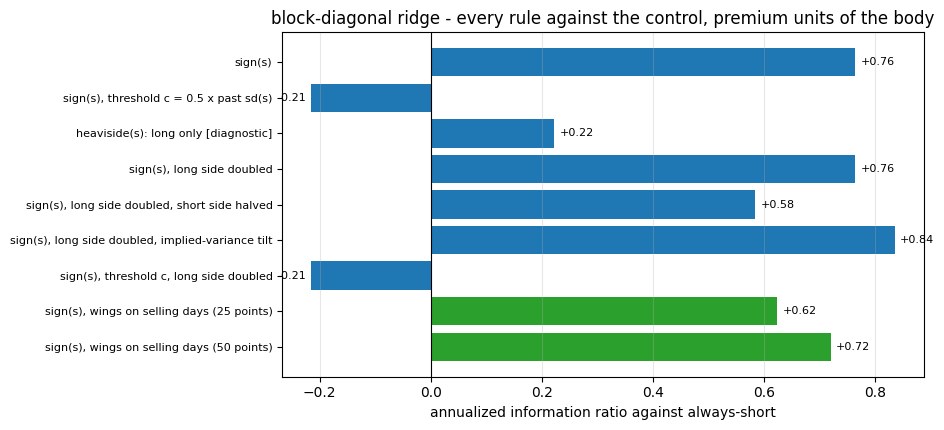

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530_aggregate\rule_aggregate_cum_usd_blk2.png


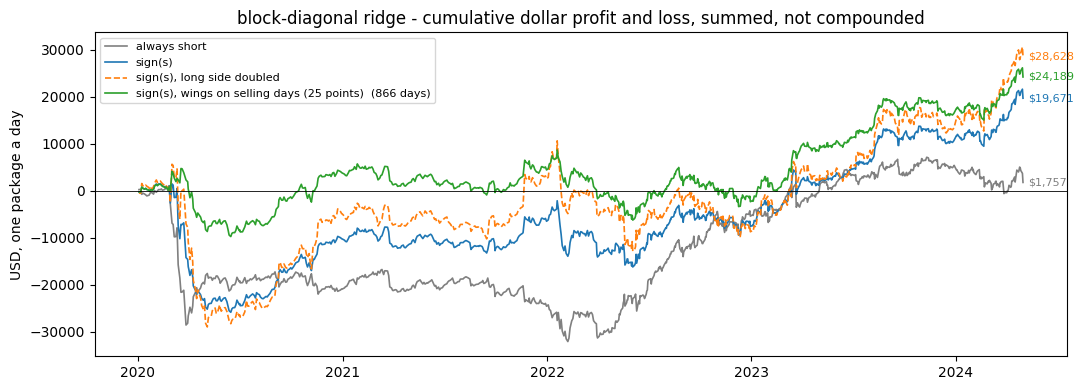

In [14]:
ir_blk2 = ir.xs(LABEL["blk2"], level="forecast")["IR_ann"].reindex(
    [lab for k, lab, _ in RULES if k != "always_short"])
fig, ax = plt.subplots(figsize=(9.5, 4.4))
colors = ["C0" if "wings" not in lab else "C2" for lab in ir_blk2.index]
ax.barh(range(len(ir_blk2)), ir_blk2.to_numpy(), color=colors)
ax.set_yticks(range(len(ir_blk2)))
ax.set_yticklabels(ir_blk2.index, fontsize=8)
ax.invert_yaxis()
ax.axvline(0.0, color="k", lw=0.8)
for i, v in enumerate(ir_blk2.to_numpy()):
    ax.annotate(f"{v:+.2f}", (v, i), xytext=(4 if v >= 0 else -4, 0), textcoords="offset points",
                va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax.set_xlabel("annualized information ratio against always-short")
ax.set_title("block-diagonal ridge - every rule against the control, premium units of the body")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "rule_aggregate_ir_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_aggregate_ir_blk2.png")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 4.0))
for key, color, ls in (("always_short", "0.5", "-"),
                       ("long_short_sign", "C0", "-"),
                       ("long_short_sign_m2", "C1", "--"),
                       ("long_short_sign_wings25", "C2", "-")):
    b = build("blk2", RULE_SPEC[key])
    usd = (b["pts"] * asl.SPX_MULTIPLIER).cumsum()
    lab = RULE_LABEL[key] + (f"  ({len(b['idx'])} days)" if key.startswith("long_short_sign_wings") else "")
    ax.plot(usd.index, usd.to_numpy(), ls, lw=1.2, color=color, label=lab)
    ax.annotate(f"${usd.iloc[-1]:,.0f}", (usd.index[-1], usd.iloc[-1]), xytext=(4, 0),
                textcoords="offset points", fontsize=8, va="center", color=color)
ax.axhline(0.0, color="k", lw=0.6)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("USD, one package a day")
ax.set_title("block-diagonal ridge - cumulative dollar profit and loss, summed, not compounded")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "rule_aggregate_cum_usd_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_aggregate_cum_usd_blk2.png")
display(fig)
plt.close(fig)


## 14. What this does not show

Extra notional on the buying side is a pure scale on that side: it
multiplies the $+0.12$ days and the many $-1$ days by exactly the same
number, so it moves the mean and the standard deviation of the buying
side's contribution together and buys no information. A threshold does
not raise $E[R\mid\text{buy}]$ if the decile picture of the settlement
return against the signal is a step rather than a slope — it only moves
days across the step, and the deck's regression section already found
the step. Wings buy a floor, not a Sharpe ratio: they bound the worst
day and make a fraction of wealth admissible, and they pay for that
bound out of the mean.

Three further things this notebook is silent about. It does not compare
forecasts — the seven columns are there so that no rule can be a
property of one table, not so that a winner can be read off. It does not
show that a higher share of correct signs is a better forecast; hit rate
is not the loss this trade is scored on. And it does not show any of
this net of the costs a real account pays beyond the entry spread:
exercise and assignment, financing on posted margin, and the days when
the size shown here is larger than the quoted depth.